In [79]:
#Load packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
import xgboost as xgb

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import shap

# Load Datasets

In [80]:
# Load the 1st dataset
df = pd.read_csv('Shopping_Behaviour_Dataset.csv')

# Overview of the data
print(df.shape) #shape of the data
print(df.columns.tolist()) #list of columns
print(df.head()) #sample entries
print(df.info()) #data types
print(df.isnull().sum()) #check for nulls

(3900, 18)
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Y

In [81]:
#Load the 2nd dataset
df2 = pd.read_csv('Ecommerce_Consumer_Behavior_Analysis_Data.csv')

#Overview of the data
print(df2.shape) #shape of the data
print(df2.columns.tolist()) #list of columns
print(df2.head()) #sample entries
print(df2.info()) #data types
print(df2.isnull().sum()) #check for nulls

(1000, 28)
['Customer_ID', 'Age', 'Gender', 'Income_Level', 'Marital_Status', 'Education_Level', 'Occupation', 'Location', 'Purchase_Category', 'Purchase_Amount', 'Frequency_of_Purchase', 'Purchase_Channel', 'Brand_Loyalty', 'Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Social_Media_Influence', 'Discount_Sensitivity', 'Return_Rate', 'Customer_Satisfaction', 'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method', 'Time_of_Purchase', 'Discount_Used', 'Customer_Loyalty_Program_Member', 'Purchase_Intent', 'Shipping_Preference', 'Time_to_Decision']
   Customer_ID  Age  Gender Income_Level Marital_Status Education_Level  \
0  37-611-6911   22  Female       Middle        Married      Bachelor's   
1  29-392-9296   49    Male         High        Married     High School   
2  84-649-5117   24  Female       Middle         Single        Master's   
3  48-980-6078   29  Female       Middle         Single        Master's   
4  91-170-9072   33  Female       Middle        

# Compare Datasets

Quick functions such as value_counts and the shape functions from above were used to check if there could be any columns that could be put together to create one dataset. The findings were below:

Columns which existed in both datasets:
* Customer ID
* Age

Columns which existed in both, but will need to be modified to be more uniform: 
* Gender --> Exists in both, but other categories exists in Dataset 2, and will need to be streamlined in Dataset 1
* Category and Purchase_Category
* Purchase Amount (USD) & Purchase_Amount
* Review Rating & Customer_Satisfaction
* Discount Applied & Discount_Used
* Subscription Status & Customer_Loyalty_Program_Member
* Payment Method & Payment_Method

The rest of the columns are unable to be merged together because either one does not exist in the other dataset, or the values are missing data to enable the 2 columns to be merged.

In [82]:
#Shipping Type was checked, but decided not to use because it is not the same as Shipping_Preference
df['Shipping Type'].unique()

array(['Express', 'Free Shipping', 'Next Day Air', 'Standard',
       '2-Day Shipping', 'Store Pickup'], dtype=object)

In [83]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [84]:
df2.head()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


# Merge 2 Datasets

Both datasets will be merged after each dataset has been cleaned. In more detail, the following changes have been performed:

**Dataset 1:**
* *payment_method*: Change 'Venmo' and 'Bank Transfer' to 'Other'
* *category*: Change 'Footwear' and 'Outerwear' to 'Clothing', change 'Accesories' to 'Jewelry & Accessories'
* *purchase_amount* and *rating*: Change data types to float

**Dataset 2:**
* *rating*: Since this is over 10, divide by 2 to make it over by 5, similar to Dataset 1
* *purchase_amount*: Remove $ and , from the column values; change to numeric type
* *discount* and *subscribed*: Change 'True' to 'Yes' and 'False' to 'No'
* *cust_id*: Remove '-' from ID then change to a number so customer IDs can be the index
* *gender*: Change gender types other than 'Male' and 'Female' to 'Queer'

In [85]:
#Fix dataset 1
df_fix = df[['Customer ID', 'Age', 'Gender', 'Category', 'Purchase Amount (USD)', 'Review Rating', 'Discount Applied', 'Subscription Status', 'Payment Method']]
df_fix = df_fix.rename(columns={"Customer ID": "cust_id", "Age": "age", "Gender": "gender", "Category": "category", "Purchase Amount (USD)": "purchase_amount", "Review Rating": "rating", "Discount Applied": "discount", "Subscription Status": "subscribed", "Payment Method": "payment_method"})
df_fix

,cust_id,age,gender,category,purchase_amount,rating,discount,subscribed,payment_method
0,1,55,Male,Clothing,53,3.1,Yes,Yes,Venmo
1,2,19,Male,Clothing,64,3.1,Yes,Yes,Cash
2,3,50,Male,Clothing,73,3.1,Yes,Yes,Credit Card
3,4,21,Male,Footwear,90,3.5,Yes,Yes,PayPal
4,5,45,Male,Clothing,49,2.7,Yes,Yes,PayPal
...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Clothing,28,4.2,No,No,Venmo
3896,3897,52,Female,Accessories,49,4.5,No,No,Bank Transfer
3897,3898,46,Female,Accessories,33,2.9,No,No,Venmo
3898,3899,44,Female,Footwear,77,3.8,No,No,Venmo


In [86]:
#Check payment method and ensure it matches with dataset 2
df_fix['payment_method'].unique()

array(['Venmo', 'Cash', 'Credit Card', 'PayPal', 'Bank Transfer',
       'Debit Card'], dtype=object)

In [87]:
# Source - https://stackoverflow.com/a/60946524
# Posted by tianlinhe, modified by community. See post 'Timeline' for change history
# Retrieved 2026-08-05, License - CC BY-SA 4.0

#Change values to match with dataset 2
df_fix['payment_method'] = df_fix['payment_method'].apply(lambda a: str(a).replace('Venmo','Other'))
df_fix['payment_method'] = df_fix['payment_method'].apply(lambda a: str(a).replace('Bank Transfer','Other'))

In [88]:
#Double check
df_fix['payment_method'].unique()

array(['Other', 'Cash', 'Credit Card', 'PayPal', 'Debit Card'],
      dtype=object)

In [89]:
#Check product category
df_fix['category'].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

In [90]:
#Change values to match with dataset 2
df_fix['category'] = df_fix['category'].apply(lambda a: str(a).replace('Footwear','Clothing'))
df_fix['category'] = df_fix['category'].apply(lambda a: str(a).replace('Outerwear','Clothing'))
df_fix['category'] = df_fix['category'].apply(lambda a: str(a).replace('Accessories','Jewelry & Accessories'))

In [91]:
#Convert data types
df_fix['purchase_amount'].astype(float)
df_fix['rating'].astype(float)

df_fix.head()

,cust_id,age,gender,category,purchase_amount,rating,discount,subscribed,payment_method
0,1,55,Male,Clothing,53,3.1,Yes,Yes,Other
1,2,19,Male,Clothing,64,3.1,Yes,Yes,Cash
2,3,50,Male,Clothing,73,3.1,Yes,Yes,Credit Card
3,4,21,Male,Clothing,90,3.5,Yes,Yes,PayPal
4,5,45,Male,Clothing,49,2.7,Yes,Yes,PayPal


In [92]:
#Check gender types
df_fix['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [93]:
#Fix dataset 2
df2_fix = df2[['Customer_ID', 'Age', 'Gender', 'Purchase_Category', 'Purchase_Amount', 'Customer_Satisfaction', 'Discount_Used', 'Customer_Loyalty_Program_Member', 'Payment_Method']]
df2_fix = df2_fix.rename(columns={"Customer_ID": "cust_id", "Age": "age", "Gender": "gender", "Purchase_Category": "category", "Purchase_Amount": "purchase_amount", "Customer_Satisfaction": "rating", "Discount_Used": "discount", "Customer_Loyalty_Program_Member": "subscribed", "Payment_Method": "payment_method"})
df2_fix

,cust_id,age,gender,category,purchase_amount,rating,discount,subscribed,payment_method
0,37-611-6911,22,Female,Gardening & Outdoors,$333.80,7,True,False,Credit Card
1,29-392-9296,49,Male,Food & Beverages,$222.22,5,True,False,PayPal
2,84-649-5117,24,Female,Office Supplies,$426.22,7,True,True,Debit Card
3,48-980-6078,29,Female,Home Appliances,$101.31,1,True,True,Other
4,91-170-9072,33,Female,Furniture,$211.70,10,False,False,Debit Card
...,...,...,...,...,...,...,...,...,...
995,20-562-2569,44,Female,Mobile Accessories,$463.67,4,True,False,PayPal
996,41-366-4205,50,Female,Gardening & Outdoors,$69.78,6,True,False,Cash
997,77-241-7621,26,Male,Food & Beverages,$453.37,6,True,True,Credit Card
998,53-091-2176,21,Female,Baby Products,$106.15,5,True,True,Cash


In [94]:
#Check payment method types
df2_fix['payment_method'].unique()

array(['Credit Card', 'PayPal', 'Debit Card', 'Other', 'Cash'],
      dtype=object)

In [95]:
#Check all types of categories
df2_fix['category'].unique()

array(['Gardening & Outdoors', 'Food & Beverages', 'Office Supplies',
       'Home Appliances', 'Furniture', 'Books', 'Sports & Outdoors',
       'Mobile Accessories', 'Luxury Goods', 'Animal Feed', 'Health Care',
       'Hotels', 'Packages)', 'Electronics', 'Software & Apps',
       'Baby Products', 'Toys & Games', 'Arts & Crafts',
       'Health Supplements', 'Groceries', 'Clothing',
       'Beauty & Personal Care', 'Travel & Leisure (Flights',
       'Jewelry & Accessories'], dtype=object)

In [96]:
#Change rating from over 10 to over 5
df2_fix['rating'] = df2_fix['rating'].astype(float)/2

In [97]:
#Clean purchase_amount to just the number by removing $ and , and changing to numeric type
df2_fix['purchase_amount'] = df2_fix['purchase_amount'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df2_fix['purchase_amount'] = pd.to_numeric(df2_fix['purchase_amount'], errors='coerce')

In [98]:
#Change 'True' to 'Yes' and 'False' to 'No'
df2_fix['discount'] = df2_fix['discount'].apply(lambda a: str(a).replace('True','Yes'))
df2_fix['discount'] = df2_fix['discount'].apply(lambda a: str(a).replace('False','No'))

df2_fix['subscribed'] = df2_fix['subscribed'].apply(lambda a: str(a).replace('True','Yes'))
df2_fix['subscribed'] = df2_fix['subscribed'].apply(lambda a: str(a).replace('False','No'))

In [99]:
#Remove - from customer ID then change to a number
df2_fix['cust_id'] = df2_fix['cust_id'].astype(str).str.replace('-', '', regex=False)
df2_fix['cust_id'] = pd.to_numeric(df2_fix['cust_id'], errors='coerce')

In [100]:
#Get all unique genders
df2_fix['gender'].unique()

array(['Female', 'Male', 'Bigender', 'Genderfluid', 'Non-binary',
       'Polygender', 'Agender', 'Genderqueer'], dtype=object)

In [101]:
#For simplicity, change other gender types to Queer
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Bigender','Queer'))
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Genderfluid','Queer'))
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Non-binary','Queer'))
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Polygender','Queer'))
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Agender','Queer'))
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Genderqueer','Queer'))

In [102]:
df2_fix.head()

,cust_id,age,gender,category,purchase_amount,rating,discount,subscribed,payment_method
0,376116911,22,Female,Gardening & Outdoors,333.80,3.5,Yes,No,Credit Card
1,293929296,49,Male,Food & Beverages,222.22,2.5,Yes,No,PayPal
2,846495117,24,Female,Office Supplies,426.22,3.5,Yes,Yes,Debit Card
3,489806078,29,Female,Home Appliances,101.31,0.5,Yes,Yes,Other
4,911709072,33,Female,Furniture,211.70,5.0,No,No,Debit Card


In [103]:
#Merge 2 datasets
merged_df = pd.concat([df_fix, df2_fix], axis=0)

#Set customer ID as index so it will not be included as an input in the model
merged_df = merged_df.set_index('cust_id')
merged_df.head()

,age,gender,category,purchase_amount,rating,discount,subscribed,payment_method
cust_id,,,,,,,,
1,55,Male,Clothing,53.0,3.1,Yes,Yes,Other
2,19,Male,Clothing,64.0,3.1,Yes,Yes,Cash
3,50,Male,Clothing,73.0,3.1,Yes,Yes,Credit Card
4,21,Male,Clothing,90.0,3.5,Yes,Yes,PayPal
5,45,Male,Clothing,49.0,2.7,Yes,Yes,PayPal


In [104]:
merged_df.shape

(4900, 8)

In [105]:
merged_df.columns

Index(['age', 'gender', 'category', 'purchase_amount', 'rating', 'discount',
       'subscribed', 'payment_method'],
      dtype='object')

# ML Model 1: kMeans Clustering

To identify loyal customers, a K-Means clustering model was used to group customers based on their demographic and purchase behavior. The process followed these steps:

1. **Pre-process data** — scaled numeric features using `StandardScaler` and encode categorical features using *one-hot encoding*.
2. **Determine the optimal number of clusters (k)** — Used the elbow method (inertia) and silhouette score to identify the best number of clusters to use
3. **Profile each cluster** — Summarised customer attributes per cluster to characterise each group
4. **Visualize the clusters** — Plotted values using a scatterplot (on a sample pair of key features) to inspect clusters
5. **Identify main drivers of cluster formation** — Used a centroid heatmap to determine which features most strongly distinguish clusters from one another

In [106]:
# Convert Yes/No to 1/0
merged_df['discount'] = merged_df['discount'].map({'Yes': 1, 'No': 0})
merged_df['subscribed'] = merged_df['subscribed'].map({'Yes': 1, 'No': 0})

numeric_cols = ['age', 'purchase_amount', 'rating', 'discount', 'subscribed']
categorical_cols = ['gender', 'category', 'payment_method']

In [107]:
# preprocess numerical cols above using standard scaler, and categorical using one hot encoding
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),('cat', OneHotEncoder(drop='first'), categorical_cols)])
#fit and transform data after using preprocessor
X = preprocessor.fit_transform(merged_df)

#use elbow method and silhouette score to get optimal k clusters
inertia, sil = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=33, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))

#list values in a table
k_scores = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertia,
    'silhouette': sil})

#print values
print(k_scores)

   k       inertia  silhouette
0  2  25076.867406    0.228806
1  3  20132.622846    0.260602
2  4  18028.954640    0.205468
3  5  16321.673611    0.209350
4  6  15417.958629    0.194953
5  7  14282.837154    0.202301
6  8  13745.454818    0.205128
7  9  13259.488072    0.175684


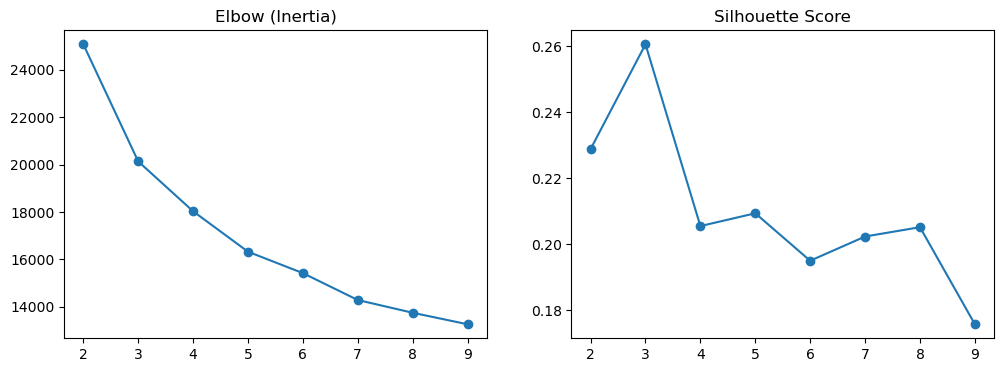

In [121]:
#plot inertia and silhouette scores to visualise best k
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_range, inertia, marker='o'); ax[0].set_title('Elbow (Inertia)')
ax[1].plot(k_range, sil, marker='o'); ax[1].set_title('Silhouette Score')
#plt.savefig('elbow_sil_graphs.png', dpi=300, bbox_inches='tight')
plt.show()

Looking at the inertia via the elbow graph, it naturally decreases the more k values are added, but the inertia drop is highest when k goes from 2 to 3. This indicates that a k of 3 can provide the most meaningful cluster groupings. Additionally, the silhouette score is also the greatest at **k = 3** with a silhouette score of 0.261. From these, we can see that the clusters are most distinguished at around the k = 3 mark.

However, since the silhouette score is low at only 0.261, it may indicate that there are weak or little to no separation among the clusters. Since this silhouette score is the best performing among the k iterations, we proceed with k = 3.

In [109]:
#fit kmeans model with k=3
kmeans = KMeans(n_clusters=3, random_state=33, n_init=10)
merged_df['cluster'] = kmeans.fit_predict(X)

In [110]:
#overview of the clusters
print(merged_df.groupby('cluster')[numeric_cols].mean())
print("\n")
print(merged_df.groupby('cluster')['category'].value_counts(normalize=True))

               age  purchase_amount    rating  discount  subscribed
cluster                                                            
0        33.776712       322.742918  2.314384  0.517808    0.490411
1        43.680430        64.262658  3.753505  0.000000    0.008602
2        43.337127        66.738141  3.744119  0.986450    0.631978


cluster  category             
0        Home Appliances          0.056164
         Jewelry & Accessories    0.054795
         Sports & Outdoors        0.052055
         Packages)                0.050685
         Electronics              0.047945
                                    ...   
2        Office Supplies          0.002710
         Software & Apps          0.002710
         Gardening & Outdoors     0.002168
         Hotels                   0.002168
         Packages)                0.001626
Name: proportion, Length: 72, dtype: float64


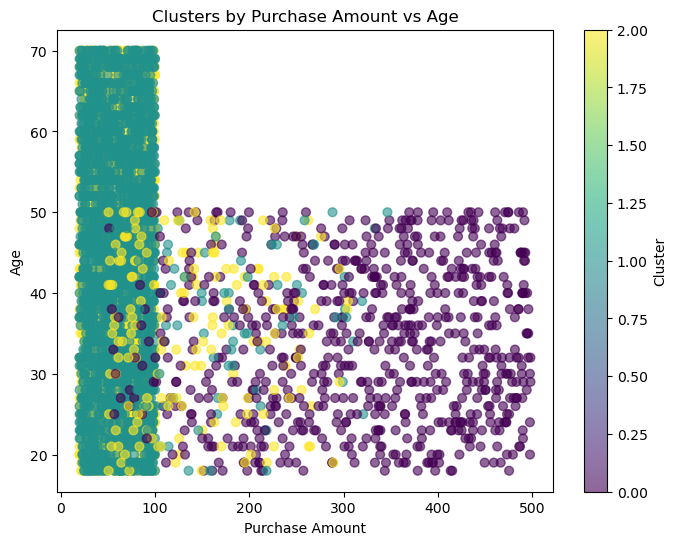

In [122]:
#plot clusters using a scatterplot for sample features age and purchase_amount
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    merged_df['purchase_amount'], merged_df['age'],
    c=merged_df['cluster'], cmap='viridis', alpha=0.6, s=40
)
plt.xlabel('Purchase Amount')
plt.ylabel('Age')
plt.title('Clusters by Purchase Amount vs Age')
plt.colorbar(scatter, label='Cluster')
#plt.savefig('cluster_scatterplot.png', dpi=300, bbox_inches='tight')
plt.show()

A scatterplot was created to visualise customer clusters based on purchase_amount and age. The points are coloured based on their cluster assignment  (cluster 0 = purple, cluster 1 = teal, cluster 2 = yellow).

The plot shows a clear divide among the clusters from purchase_amount = 100. Above this, points are almost entirely from cluster 0, with ages spanning 18 to 50. This aligns with the earlier cluster profiling which identified cluster 0 as the high-spending segment. Below the threshold, clusters 1 and 2 are heavily mixed and make up this range. Both clusters are also mixed from the age ranges 18 to 70. Notably, older customers are absent from the high spend region of cluster 0.

Though the graph is able to distinctly show cluster 0 and isolate it along the purchase_amount axis, clusters 1 and 2 substantially overlap and suggest that  purchase_amount and age may not be enough to fully distinguish these 2 groups. The centroid heatmap below investigates this further.

Additionally, the clusters form rough, straight rectangles rather than more natural clusters typically expected from clustering methods. This may be an effect of the datasets that were used, since the datasets were sourced from Kaggle. As such, it is possible that features such as purchase_amount may have been artificially generated, which may not necessarily reflect real world data behaviour. This is a real limitation of the dataset, which in turn influences the quality of insights derivable from the machine learning models used here. 

In [112]:
#exclude 'category' since this will have its own table
heatmap_cat_cols = [col for col in categorical_cols if col != 'category']

#create dummies for the categorical columns and group by cluster
categorical_dummies = pd.get_dummies(merged_df[heatmap_cat_cols], drop_first=False)
categorical_dummies['cluster'] = merged_df['cluster']
categorical_profile = categorical_dummies.groupby('cluster').mean()

#get the means of the numerical columns
cluster_profile = merged_df.groupby('cluster')[numeric_cols].mean()

#merge both
full_profile = pd.concat([cluster_profile, categorical_profile], axis=1)

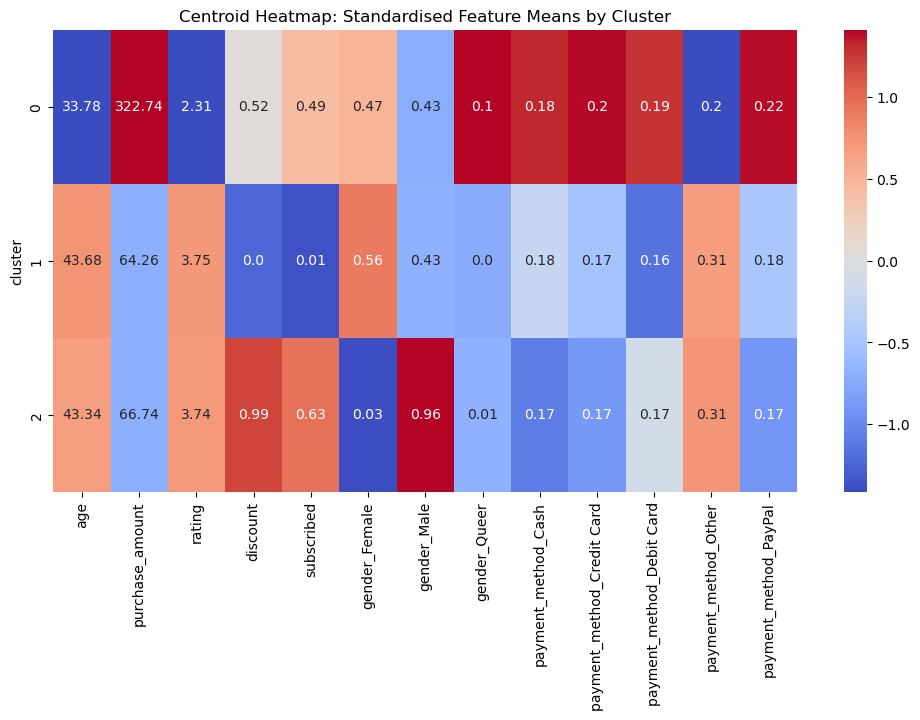

In [123]:
#create a centroid heatmap
profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(full_profile),
    index=full_profile.index,
    columns=full_profile.columns)

plt.figure(figsize=(12, 6))
sns.heatmap(profile_scaled, annot=full_profile.round(2), fmt='', cmap='coolwarm', center=0)
plt.title('Centroid Heatmap: Standardised Feature Means by Cluster')

#plt.savefig('centroid_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

To further investigate which features most influence the clustering, a centroid heatmap was created. This heatmap displays the standardised feature means per cluster. 

Cluster 0 is most strongly defined by purchase_amount at a value of *322.74*. This is approximately 5 times higher than clusters 1 and 2 (around *64-67*). It also shows a higher share of gender_Queer customers (0.1 versis 0.01 in other clusters), as well as generally higher share across all payment_method categories. However, it is worth nothing that the difference in payment method shares may be a result of the standardisation techniques used rather than actual distinguishing data features. 

Cluster 1 seems to have no notable feature which stands out, aside from having the lowest shares for discount (0.0) and subscribed (0.0) among the clusters. In fact, most of its other features have shares near 0.0, making it the least differentiated cluster.  

Cluster 2 is mostly defined by its larger share of males (0.96), people using discounts (0.99), and shares of customers having a high subscription rate (0.63).

In [114]:
#Just for data vieweing purposes, group the clusters together by category and check proportions
top_categories = (
    merged_df.groupby('cluster')['category']
    .value_counts(normalize=True)
    .groupby(level=0)
    .head(5)
    .reset_index(name='proportion'))
print(top_categories)
#print(top_categories.to_latex(index=False))

    cluster               category  proportion
0         0        Home Appliances    0.056164
1         0  Jewelry & Accessories    0.054795
2         0      Sports & Outdoors    0.052055
3         0              Packages)    0.050685
4         0            Electronics    0.047945
5         1               Clothing    0.659785
6         1  Jewelry & Accessories    0.301505
7         1                 Hotels    0.003441
8         1          Arts & Crafts    0.003011
9         1      Sports & Outdoors    0.003011
10        2               Clothing    0.615718
11        2  Jewelry & Accessories    0.297561
12        2            Electronics    0.007046
13        2              Furniture    0.007046
14        2     Health Supplements    0.005962


Looking at the distribution of purchase item categories per cluster, clusters 1 and 2 show that they both purchase Clothing (~60%) and Jewelry & Accessories (~30%) the most. In contrast, cluster 0 shows no dominant category in their purchases. The top 5 categories it purchases are each around 5%, indicating that perhaps these customers purchase a variety of items, instead of focusing on 1 or 2 like the other clusters. 

Interestingly, despite cluster 0 not having any distinct category proportion, it still has the highest average purchase amounts. This may indicate that cluster 0 is composed of customers who may make more higher-value one off purchases (such as home appliances or electronics), rather than lower-value and more frequent purchases like those from cluster 1 and 2.

This adds an interesting dimension to cluster 0's profile: despite not favoring any single category, it has by far the highest average purchase amount (~$323) of the three clusters. This suggests cluster 0 may represent customers making larger, more varied, possibly higher-value one-off purchases (e.g., appliances, electronics) across categories, rather than being defined by a specific product preference — differentiating them from clusters 1 and 2, whose spending is concentrated in lower-cost, higher-frequency categories like clothing and accessories.

# ML Model 2: XGBoost

The second machine learning model, XGBoost, was used to predict the `subscribed` column. We treat this as an indication of customer loyalty. That is, a customer who is subscribed to the store's loyalty program is assumed to be a loyal customer. The following steps were performed:

1. **Split the data:** Divide features into the target and predictor features
2. **Train the model:** Fit XGBoost to the training features and target. Use GridSearchCV to find the optimal hyperparameters
3. **Evaluate model performance:** Use classification metrics and SHAP to assess predictive accuracy and analyse feature influence

In [115]:
#identify the target column and the other predictive features
target = 'subscribed'
features = ['age', 'gender', 'category', 'purchase_amount', 'rating',
            'discount', 'payment_method']

#create X for input features and Y for output or target
X = merged_df[features].copy()
y = merged_df[target]

#we convert back categoricals to category data type, since XGBoost can use these
for col in ['gender', 'category', 'payment_method']:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=33, stratify=y) #we stratify to preserve the same proportions

In [116]:
#grad for gridsearch, to get optimal parameters
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

base_model = xgb.XGBClassifier(
    enable_categorical=True,
    eval_metric='logloss', #measures how good predicted probabilities are
    random_state=33
)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='average_precision',  #takes into consideration the minority due to class imbalance
    cv=5,
    n_jobs=-1,
    verbose=2
)

#fit
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END

In [117]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=1.0,
    enable_categorical=True,
    eval_metric='logloss',
    random_state=33
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

results = model.evals_result()

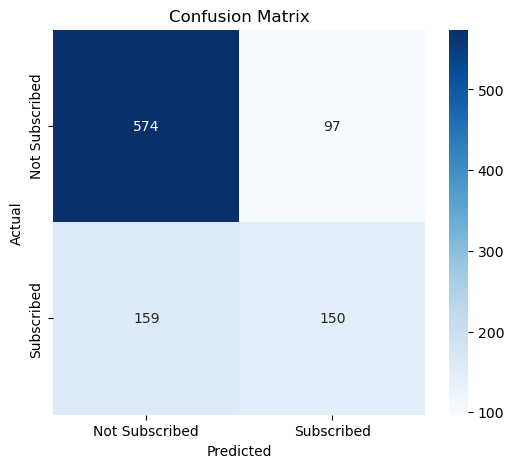

In [125]:
#model's predictions
preds = model.predict(X_test)

#probability of being subscribed
probs = model.predict_proba(X_test)[:, 1]

#visualise confusion matrix
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Subscribed', 'Subscribed'],
            yticklabels=['Not Subscribed', 'Subscribed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
#plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [126]:
#print classification report and AUC
print(classification_report(y_test, preds))
print("AUC:", round(roc_auc_score(y_test, probs), 3))

#output for latex
#report_dict = classification_report(y_test, preds, output_dict=True)
#report_df = pd.DataFrame(report_dict).transpose().round(3)
#print(report_df.to_latex())

              precision    recall  f1-score   support

           0       0.78      0.86      0.82       671
           1       0.61      0.49      0.54       309

    accuracy                           0.74       980
   macro avg       0.70      0.67      0.68       980
weighted avg       0.73      0.74      0.73       980

AUC: 0.845
\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
0 & 0.783000 & 0.855000 & 0.818000 & 671.000000 \\
1 & 0.607000 & 0.485000 & 0.540000 & 309.000000 \\
accuracy & 0.739000 & 0.739000 & 0.739000 & 0.739000 \\
macro avg & 0.695000 & 0.670000 & 0.679000 & 980.000000 \\
weighted avg & 0.728000 & 0.739000 & 0.730000 & 980.000000 \\
\bottomrule
\end{tabular}



The confusion matrix shows that the majority of Class 0 (not subscribed) customers were correctly predicted by the model. However, 159 of customers who actually subscribed were misclassified as false negatives, meaning that the model failed to identify them as subscribed. In fact, of all the 309 actual subscribers in the test set, only 150 customers were correctly identified (approximately 49%).

Now looking at the classification report, the same patterns are seen. The model performs well on Class 0, where its precision is 0.78 and recall is 0.86, but it performs worse on Class 1. For that class, it only has a precision of 0.61 and a recall of 0.49. 

Overall, the accuracy is at 0.74, which is also possibly inflated by the model's strong performance on correctly predicting the majority class of customers who are not subscribed. It does not accurately reflect how inaccurately is has been able to identify loyal subscribers.

Since the AUC score is 0.845, then this means the model is still effective ranking customers based on their likelihood to subscribe. However, although it assigns higher probabilities to actual subscribers, the model uses a default 0.5 classification threshold, which may have affected the classification of these actual subscribers to become non subscribers instead.

This behaviour where the model has a high ranking ability and a weak recall for Class 1 is likely due to the class imbalance in the training data, where most customers are non-subscribers. This biases the model into predicting the majority class. It is also possible that some subscribers do not show strong signals in the features available, and a customer subscribing may not be defined enough by the existing features. 

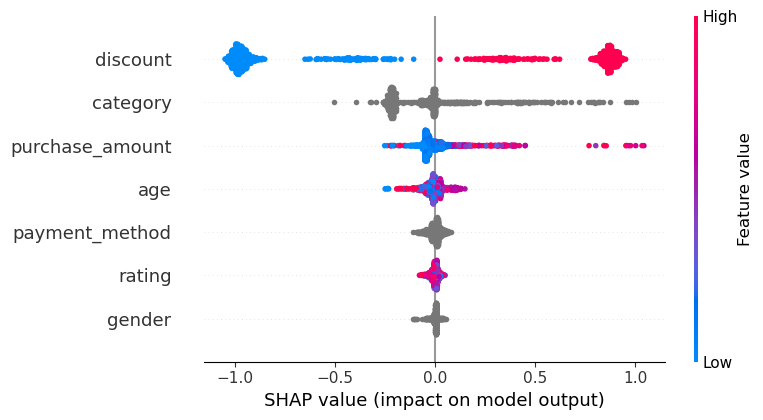

In [127]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

#which features matter most, and in which direction
shap.summary_plot(shap_values, X_test, show=False)
#plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

A SHAP explainer was created to help identify how much specific features affected a specific customer's prediction. Each row represents a feature, and the x-axis shows the SHAP value, which is essentially the feature's influence on the prediction. For numerical features, they are coloured red and blue, representing the actual value of the customer for that feature (red for high and blue for low). Categorical features cannot be ranked/ordered, so they are coloured in grey.

One notable finding is that the *discount* column dominates the model's predictions, where customers who have no discount are pushed to a 'not subscribed' prediction, and those who use discounts are more predicted as 'subscribed'. 

Next, the *category* column suggests that some categories push towards customers towards being 'subscribed', but we cannot tell from this plot alone, since categorical features are unordered. The SHAP explainer is limited in that it cannot provide further information about the specific categorical features which may have an influence on the prediction of subscribed/unsubscribed customers.

Lastly, for the *purchase_amount* column, most values are close to 0, which makes its effect more modest compared to the *discount* column. However, it also shows that slightly lower purchase amounts are associated with 'non subscribed' predictions, and higher purchases amounts with 'subscribed' predictions. Other features are not as meaningful, showing very minor influence on the model's predictions